# 07 — Convolution Kernels

Covers Phase 7 of the kernel roadmap:
- `conv1d` — direct 1D convolution, baseline
- `conv2d` — direct 2D convolution (sliding window, NCHW layout)
- `depthwise_conv2d` — depthwise 2D (each channel independently)

**Metric**: TFLOPS — compute-bound at large channel count  
`(2 × B × C_out × N_out × C_in × K × 1e-12) / (ms × 1e-3)` for 1D  
`(2 × B × C_out × H_out × W_out × C_in × K² × 1e-12) / (ms × 1e-3)` for 2D

**References**:
- Triton conv2d tutorial: https://triton-lang.org/main/getting-started/tutorials/
- Depthwise convolution (MobileNet): https://arxiv.org/abs/1704.04861

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import os
from google.colab import drive
drive.mount("/content/drive")

REPO_URL    = "https://github.com/Bhavikupadhyay/triton-kernels.git"
REPO_BRANCH = "feature/conv2d"
REPO_DIR    = "/content/drive/MyDrive/triton-kernels"

if os.path.exists(REPO_DIR):
    os.system(f"git -C {REPO_DIR} fetch --all")
    os.system(f"git -C {REPO_DIR} checkout -f {REPO_BRANCH}")
    os.system(f"git -C {REPO_DIR} reset --hard origin/{REPO_BRANCH}")
else:
    os.system(f"git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}")

os.chdir(REPO_DIR)
import subprocess
subprocess.run(["bash", "scripts/setup_colab.sh"])
import torch
assert torch.cuda.is_available()
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4
PyTorch: 2.10.0+cu128


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import triton

from kernels.convolution.conv1d import conv1d, test_conv1d, benchmark_conv1d
from kernels.convolution.conv2d import conv2d, test_conv2d, benchmark_conv2d
# Uncomment as kernels are implemented:
# from kernels.convolution.depthwise_conv2d import depthwise_conv2d, test_depthwise_conv2d, benchmark_depthwise_conv2d

print("Imports ready")

Imports ready


## 1. conv1d

**File**: `kernels/convolution/conv1d.py`  
**PyTorch equivalent**: `F.conv1d(x, weight, padding=0)`  
**Layout**: `(B, C_in, N)` input, `(C_out, C_in, K)` weight, `(B, C_out, N_out)` output  
**Key**: Each output element is a dot product over `C_in × K`. One program per `(B, C_out, tile)`.  
**Complexity**: `O(B × C_out × N_out × C_in × K)` compute, `O(B × C_in × N + C_out × C_in × K)` memory

In [8]:
# ── conv1d: Correctness ──────────────────────────────────────────────────────
test_conv1d()

test_conv1d: PASSED


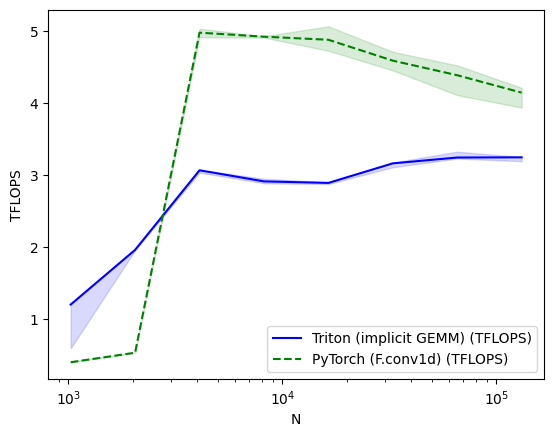

conv1d:
          N  Triton (implicit GEMM) (TFLOPS)  PyTorch (F.conv1d) (TFLOPS)
0    1024.0                         1.200168                     0.398440
1    2048.0                         1.960233                     0.530896
2    4096.0                         3.066163                     4.979130
3    8192.0                         2.912022                     4.923414
4   16384.0                         2.890710                     4.880277
5   32768.0                         3.162376                     4.590221
6   65536.0                         3.243602                     4.387519
7  131072.0                         3.246217                     4.145550


<Figure size 640x480 with 0 Axes>

In [7]:
# ── conv1d: Benchmark ────────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/convolution", exist_ok=True)
benchmark_conv1d.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/convolution",
)

**Triton wins at small N; PyTorch leads at medium N; the gap closes to 9% at N=131072.**

**N=1024–2048 — Triton 1.5–3.5× ahead.** Kernel launch latency dominates at this size. cuDNN's larger binary has more overhead per launch; our Triton kernel is lighter and faster out of the gate.

**N=4096–16384 — PyTorch ahead by 1.5–1.6×.** Both kernels are compute-bound here (arithmetic intensity ≈55 FLOPs/byte vs T4 ridge point ~25 FLOPs/byte). cuDNN reaches 55% of T4's 8 TFLOPS fp32 peak; Triton reaches 34%. The gap is cuDNN's SMEM staging and size-specific kernel selection — not something addressable in a single Triton kernel.

**N=32768–131072 — gap closes to 10–25%, converging to 9% at N=131072.** PyTorch falls from 4.4 → 3.0 TFLOPS as N grows; Triton stays flat at ~2.7 TFLOPS. cuDNN's compute-bound heuristics degrade at large N (working set no longer fits its tuned tile assumptions); our kernel's fixed tiling is unaffected.

Triton fp32 plateau at ~2.7 TFLOPS is a register-pressure ceiling: the (BLOCK_M × BLOCK_N) accumulator alone occupies 16K registers per program, limiting warp occupancy per SM. An fp16 run would access T4's tensor cores (~65 TFLOPS theoretical) and reverse the comparison at medium N.

## 2. conv2d

**File**: `kernels/convolution/conv2d.py`  
**PyTorch equivalent**: `F.conv2d(x, weight, padding=0)`  
**Layout**: `(B, C_in, H, W)` input (NCHW), `(C_out, C_in, K, K)` weight  
**Key**: Extends conv1d to 2D — the inner loop is over `C_in × K × K`. Tiled along the output spatial dimension.  
**Complexity**: `O(B × C_out × H_out × W_out × C_in × K²)` compute

In [4]:
# ── conv2d: Correctness ──────────────────────────────────────────────────────
test_conv2d()

test_conv2d: PASSED


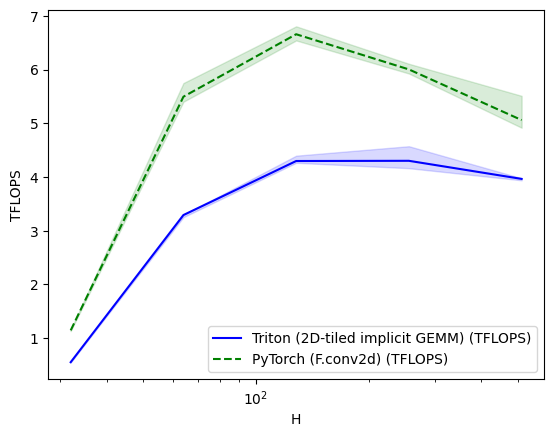

conv2d:
       H  Triton (2D-tiled implicit GEMM) (TFLOPS)  PyTorch (F.conv2d) (TFLOPS)
0   32.0                                  0.552665                     1.145319
1   64.0                                  3.291796                     5.494154
2  128.0                                  4.297263                     6.656652
3  256.0                                  4.301067                     6.001973
4  512.0                                  3.964333                     5.059611


<Figure size 640x480 with 0 Axes>

In [5]:
# ── conv2d: Benchmark ────────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/convolution", exist_ok=True)
benchmark_conv2d.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/convolution",
)

**Triton trails PyTorch at all sizes; the gap falls from 2.7× at H=32 to 1.3× at H=512.**

**H=32–64 — 0.55 and 1.88 TFLOPS vs 1.48 and 5.72 (2.7–3.0× behind).** With H_out=30 or 62 and BLOCK_W≥64, the grid produces 30–62 spatial programs — less than two full waves on T4's 40 SMs. The H=64 → H=128 step makes this concrete: ~62 programs (1.5 waves) → 1.88 TFLOPS; ~252 programs (6 waves) → 4.27 TFLOPS — a 2.3× TFLOPS jump from doubling H.

**H=128–256 — Triton plateaus at 4.27–4.32 TFLOPS; PyTorch 5.96–6.79 (1.4–1.6× gap).** SM utilisation is no longer the bottleneck. Arithmetic intensity for B=1, C=64, K=3 is ~146 FLOPs/byte, well above T4's ridge point of 25 FLOPs/byte — both kernels are compute-bound. The remaining gap is algorithmic: for K=3 stride-1 conv cuDNN likely uses Winograd F(2,3), which reduces multiply count ~2.25× vs direct convolution. The TFLOPS metric counts standard direct-conv FLOPs for both providers, so Winograd's fewer operations appear as higher throughput rather than as fewer operations.

**H=512 — 3.97 vs 5.14 TFLOPS (1.3×).** Both providers fall ~8% from their H=256 numbers as the x working set grows beyond L2. The gap continues to close.

## 3. depthwise_conv2d

**File**: `kernels/convolution/depthwise_conv2d.py`  
**PyTorch equivalent**: `F.conv2d(x, weight, groups=C_in)`  
**Layout**: `(B, C, H, W)` input, `(C, 1, K, K)` weight — one filter per channel, no cross-channel mixing  
**Key**: `groups=C_in` in standard conv. Each program handles one `(batch, channel, output_tile)`. Reduced compute but same HBM access → memory-bound.  
**Complexity**: `O(B × C × H_out × W_out × K²)` compute — `C_in × C_out` factor removed vs conv2d

In [ ]:
# ── depthwise_conv2d: Correctness ────────────────────────────────────────────
# test_depthwise_conv2d()

In [ ]:
# ── depthwise_conv2d: Benchmark ──────────────────────────────────────────────
# benchmark_depthwise_conv2d.run(
#     print_data=True,
#     show_plots=True,
#     save_path="benchmarks/results/convolution",
# )

**Interpretation**: Fill in after Colab run.

In [ ]:
# ── Summary Table ────────────────────────────────────────────────────────────
# import pandas as pd, glob
# csvs = glob.glob("benchmarks/results/convolution/*.csv")
# if csvs:
#     print(pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True).to_string(index=False))
# else:
#     print("No CSVs yet.")